# LLM Colors Preference Analysis
Analyze the results of adaptive preference elicitation from LLMs on the colors domain, comparing GRUM to the Bradley-Terry baseline.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Set project root to import grums modules if needed
ROOT = Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Data
Set the `EXP_DIR` to your experiment output folder.

In [2]:
# Set experiment directory
EXP_DIR = ROOT / "results" / "llm" / "llm_colors-20260326-090020"
output_dir = EXP_DIR / "outputs"

results_by_criterion = {}
if output_dir.exists():
    for f in sorted(output_dir.glob("*.json")):
        with open(f, "r") as j:
            res = json.load(j)
            crit = res.get("criterion", f.stem.replace("run_000_criterion_", ""))
            results_by_criterion[crit] = res

if results_by_criterion:
    print(f"Loaded {len(results_by_criterion)} criteria from {EXP_DIR.name}: {list(results_by_criterion.keys())}")
else:
    print("No results found! Set EXP_DIR to a valid experiment path.")

Loaded 3 criteria from llm_colors-20260326-090020: ['social', 'personalized', 'random']


## 2. Global Preferences: GRUM vs Bradley-Terry
How does the learned intrinsic preference ($\delta$) compare to the social average (BT $\beta$)? 
We expect high correlation if prompt variations are indeed variations around a stable core.

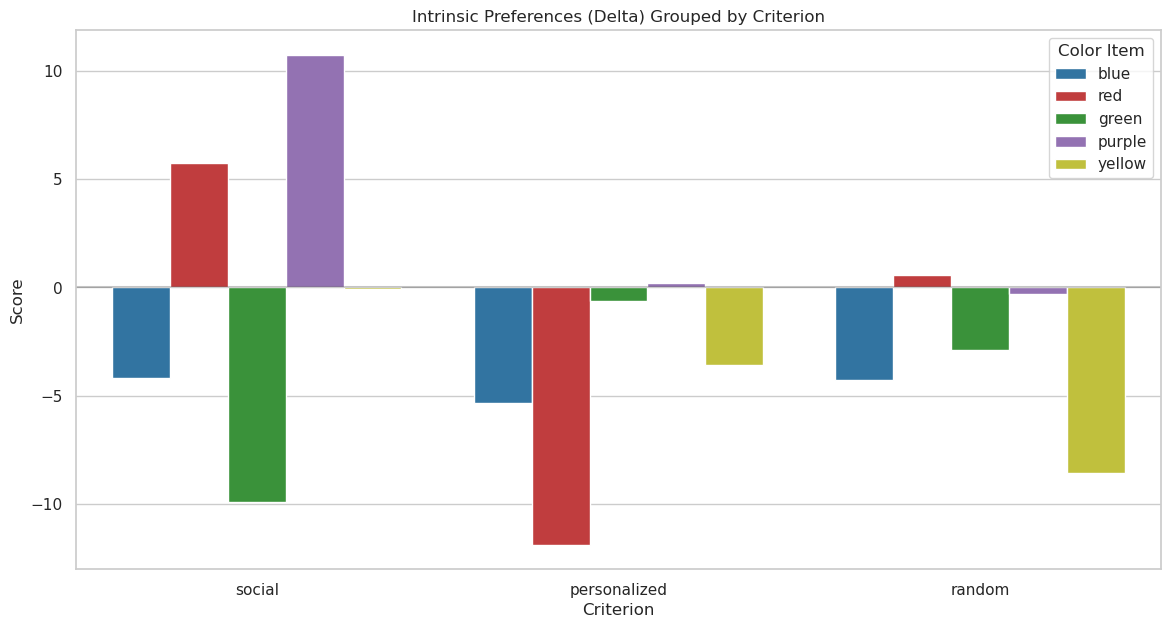

In [3]:
color_names = ["blue", "red", "green", "purple", "yellow"]
color_palette = {"blue": "blue", "red": "red", "green": "green", "purple": "purple", "yellow": "orange"} # Using orange for yellow text/visibility if needed, or stick to hex
color_palette = {"blue": "#1f77b4", "red": "#d62728", "green": "#2ca02c", "purple": "#9467bd", "yellow": "#d6d627"}

plot_data = []
for crit, res in results_by_criterion.items():
    history = res["history"]
    last_step = str(sorted(map(int, history.keys()))[-1])
    delta = history[last_step]["grum"]["delta"]
    for i, color in enumerate(color_names):
        plot_data.append({"Criterion": crit, "Color": color, "Score": delta[i]})

if plot_data:
    df_plot = pd.DataFrame(plot_data)
    
    plt.figure(figsize=(14, 7))
    # Group by Criterion, Hue by Color
    sns.barplot(data=df_plot, x="Criterion", y="Score", hue="Color", palette=color_palette)
    plt.title("Intrinsic Preferences (Delta) Grouped by Criterion")
    plt.axhline(0, color='black', alpha=0.2)
    plt.legend(title="Color Item")
    plt.show()

### 2.1 Correlation Analysis

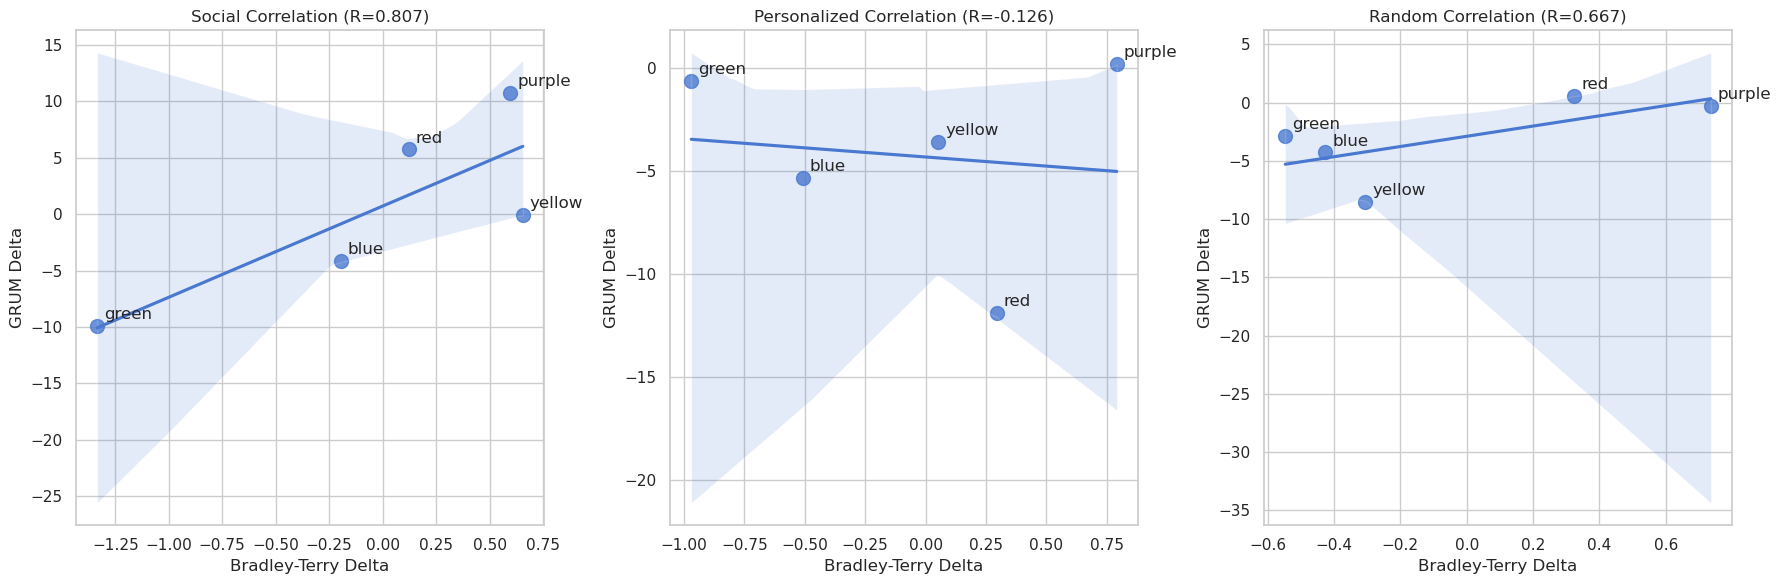

In [4]:
if results_by_criterion:
    # Show correlation for each criterion
    fig, axes = plt.subplots(1, len(results_by_criterion), figsize=(6 * len(results_by_criterion), 6))
    if len(results_by_criterion) == 1: axes = [axes]
    
    for i, (crit, res) in enumerate(results_by_criterion.items()):
        history = res["history"]
        ls = str(sorted(map(int, history.keys()))[-1])
        grum_delta = np.array(history[ls]["grum"]["delta"])
        bt_delta = np.array(history[ls]["bt"]["delta"])
        
        sns.regplot(x=bt_delta, y=grum_delta, ax=axes[i], scatter_kws={'s': 100})
        for j, name in enumerate(color_names):
            axes[i].annotate(name, (bt_delta[j], grum_delta[j]), xytext=(5, 5), textcoords='offset points')
        
        corr = np.corrcoef(bt_delta, grum_delta)[0, 1]
        axes[i].set_title(f"{crit.capitalize()} Correlation (R={corr:.3f})")
        axes[i].set_xlabel("Bradley-Terry Delta")
        axes[i].set_ylabel("GRUM Delta")
    
    plt.tight_layout()
    plt.show()

## 3. Persona Effect: Rank Reversals
Does the agent hidden state significantly alter preference ordering?

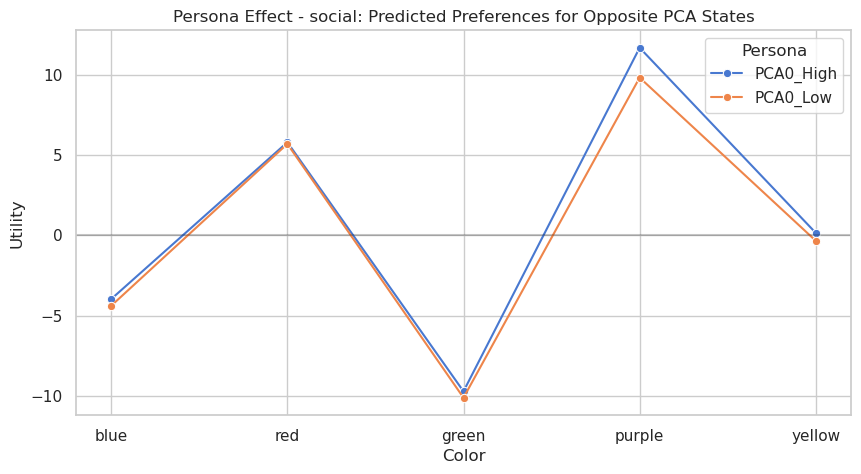

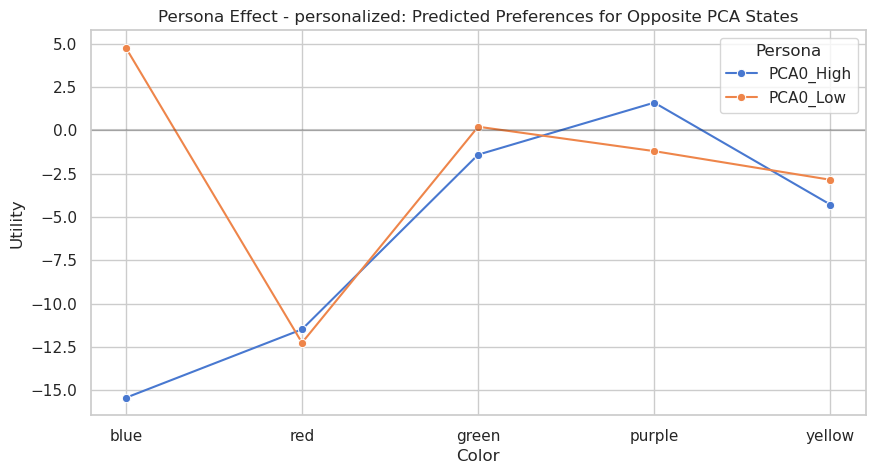

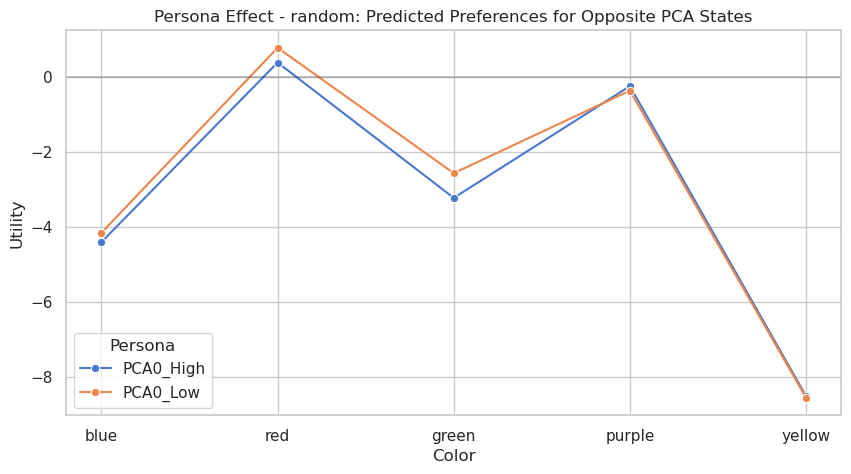

In [5]:
if results_by_criterion:
    # Show persona effect for each criterion
    for crit, res in results_by_criterion.items():
        last_step = str(sorted(map(int, res["history"].keys()))[-1])
        delta = np.array(res["history"][last_step]["grum"]["delta"])
        B = np.array(res["history"][last_step]["grum"]["interaction"])
        
        # Sample two hypothetical agents at opposite ends of the PCA space
        K, M = B.shape
        x0_pos = np.zeros(K); x0_pos[0] = 2.0
        x0_neg = np.zeros(K); x0_neg[0] = -2.0
        
        u_pos = delta + x0_pos @ B
        u_neg = delta + x0_neg @ B
        
        df_rv = pd.DataFrame({
            "Color": color_names,
            "PCA0_High": u_pos,
            "PCA0_Low": u_neg
        }).melt(id_vars="Color", var_name="Persona", value_name="Utility")
        
        plt.figure(figsize=(10, 5))
        sns.lineplot(data=df_rv, x="Color", y="Utility", hue="Persona", marker="o")
        plt.title(f"Persona Effect - {crit}: Predicted Preferences for Opposite PCA States")
        plt.axhline(0, color='black', alpha=0.2)
        plt.show()

## 4. Interaction Matrix ($B$)
Heatmap of how each PCA dimension modulates specific color preferences.

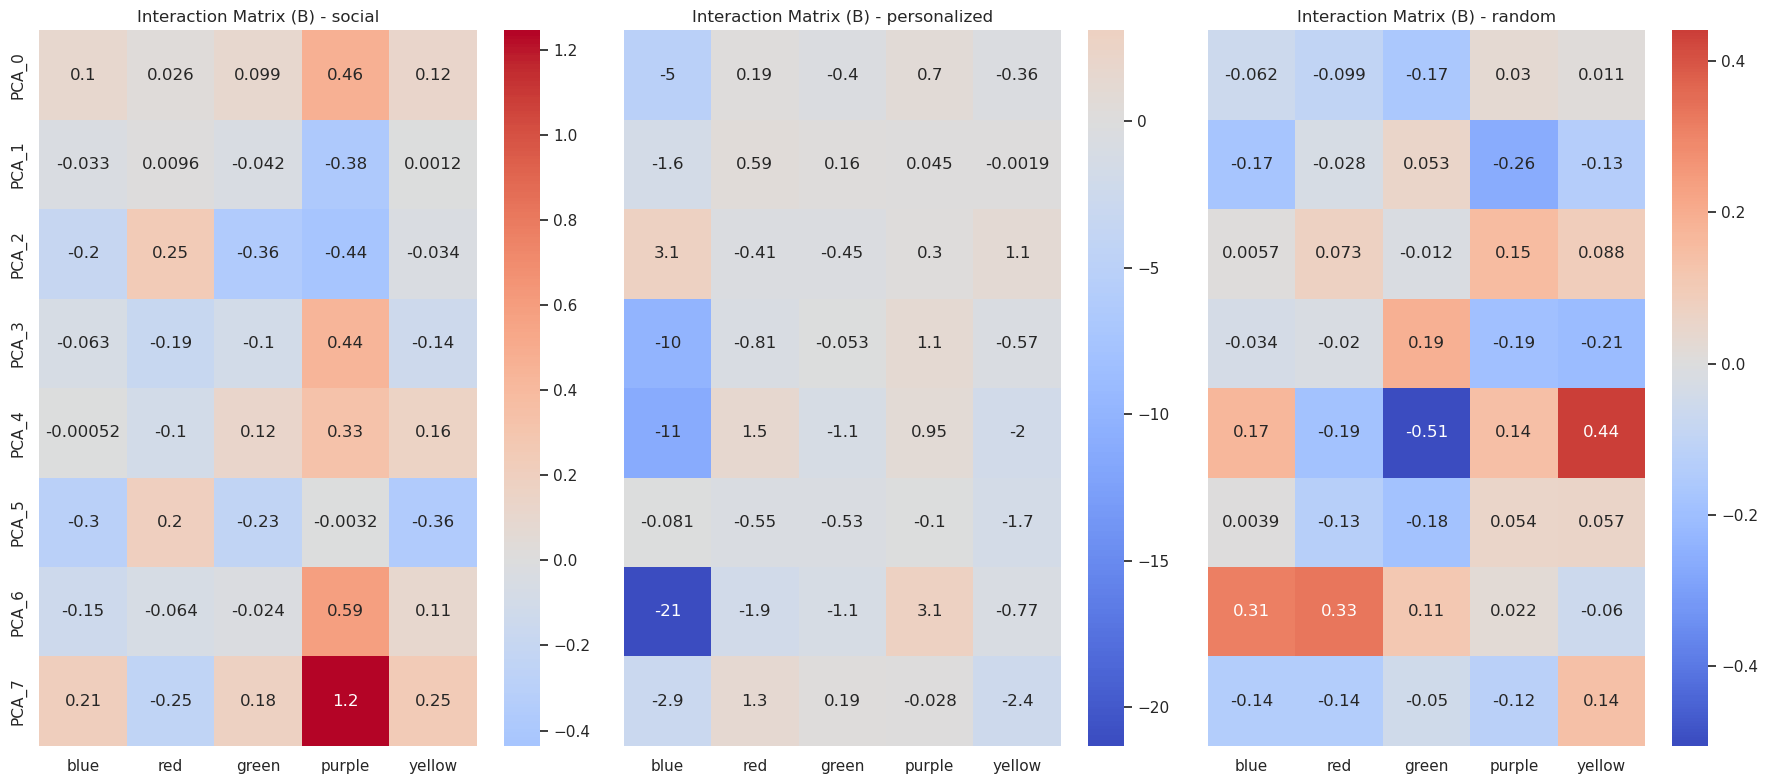

In [6]:
if results_by_criterion:
    num_crit = len(results_by_criterion)
    fig, axes = plt.subplots(1, num_crit, figsize=(6 * num_crit, 8), sharey=True)
    if num_crit == 1: axes = [axes]
    
    for i, (crit, res) in enumerate(results_by_criterion.items()):
        history = res["history"]
        ls = str(sorted(map(int, history.keys()))[-1])
        B = np.array(history[ls]["grum"]["interaction"])
        
        sns.heatmap(B, annot=True, cmap="coolwarm", center=0, ax=axes[i],
                    xticklabels=color_names, yticklabels=[f"PCA_{j}" for j in range(B.shape[0])])
        axes[i].set_title(f"Interaction Matrix (B) - {crit}")
    
    plt.tight_layout()
    plt.show()

## 5. Convergence Stability
Tracking parameter stabilization across rounds.

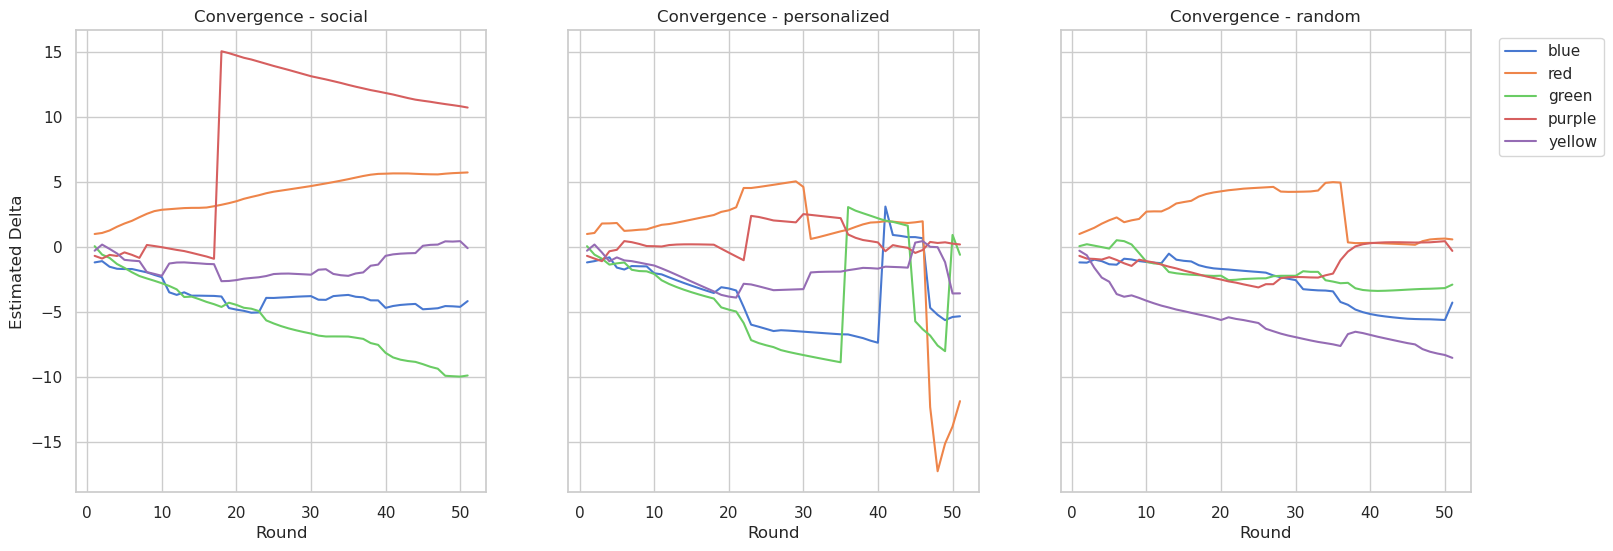

In [7]:
if results_by_criterion:
    fig, axes = plt.subplots(1, len(results_by_criterion), figsize=(18, 6), sharey=True)
    if len(results_by_criterion) == 1: axes = [axes]
    
    for i, (crit, res) in enumerate(results_by_criterion.items()):
        steps = sorted(map(int, res["history"].keys()))
        for j, c in enumerate(color_names):
            y = [res["history"][str(s)]["grum"]["delta"][j] for s in steps]
            axes[i].plot(steps, y, label=c, color=sns.color_palette()[j])
        
        axes[i].set_title(f"Convergence - {crit}")
        axes[i].set_xlabel("Round")
        if i == 0: axes[i].set_ylabel("Estimated Delta")
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()